# Analysis of Chemical Components: Cosmetic Recommendation System

**Author:** Gracie Bhandari

Choosing a new skincare product is hard, especially for people with sensitive skin, because ingredient labels are long and difficult to interpret without a chemistry background. This notebook builds a **content-based recommendation system** in which the *content* is each product's list of chemical components.

**Workflow**

1. Load and explore 1,472 Sephora skincare products
2. Clean the ingredient data (remove placeholder entries and normalize ingredient names)
3. Filter to one product category and one skin type
4. Tokenize the ingredient lists and build a binary product × ingredient (document-term) matrix
5. Measure ingredient overlap between products with **Jaccard similarity**
6. Reduce the matrix to two dimensions with **t-SNE**
7. Explore the products on an interactive **Bokeh** map
8. Compare two products and generate ranked **recommendations**

## 1. Load and explore the data

The dataset (`Dataset/cosmetics.csv`, sourced from Kaggle) contains one row per product with its category (`Label`), brand, name, price (USD), customer rating (`Rank`, 0–5), full ingredient list, and five binary skin-type flags indicating which skin types the product is suitable for.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import TSNE

# Resolve the data path whether the notebook is run from the repo root or from Notebook/
DATA_PATH = next(p for p in [Path('Dataset/cosmetics.csv'), Path('../Dataset/cosmetics.csv')] if p.exists())
REPO_ROOT = DATA_PATH.parent.parent

df = pd.read_csv(DATA_PATH)
print(f'{df.shape[0]} products, {df.shape[1]} columns')
print(f'Missing values: {df.isna().sum().sum()}  |  Duplicate products: {df.duplicated(["Brand", "Name"]).sum()}')
display(df.head())

1472 products, 11 columns
Missing values: 0  |  Duplicate products: 0


,Label,Brand,Name,Price,Rank,Ingredients,Combination,Dry,Normal,Oily,Sensitive
0,Moisturizer,LA MER,Crème de la Mer,175,4.1,"Algae (Seaweed) Extract, Mineral Oil, Petrolat...",1,1,1,1,1
1,Moisturizer,SK-II,Facial Treatment Essence,179,4.1,"Galactomyces Ferment Filtrate (Pitera), Butyle...",1,1,1,1,1
2,Moisturizer,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4,"Water, Dicaprylyl Carbonate, Glycerin, Ceteary...",1,1,1,1,0
3,Moisturizer,LA MER,The Moisturizing Soft Cream,175,3.8,"Algae (Seaweed) Extract, Cyclopentasiloxane, P...",1,1,1,1,1
4,Moisturizer,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1,"Water, Snail Secretion Filtrate, Phenyl Trimet...",1,1,1,1,1


In [2]:
SKIN_TYPES = ['Combination', 'Dry', 'Normal', 'Oily', 'Sensitive']

print('Products per category:')
print(df['Label'].value_counts().to_string())
print('\nProducts suitable for each skin type:')
print(df[SKIN_TYPES].sum().to_string())

Products per category:
Label
Moisturizer    298
Cleanser       281
Face Mask      266
Treatment      248
Eye cream      209
Sun protect    170

Products suitable for each skin type:
Combination    966
Dry            904
Normal         960
Oily           894
Sensitive      756


## 2. Clean the ingredient data

Not every row contains a usable ingredient list. Some entries are scraping placeholders such as `No Info`, `Visit the Dior boutique`, or a spreadsheet error (`#NAME?`), and some contain only a footnote (e.g. `*Plant origin.`). If these were kept, every placeholder product would be treated as a product with one shared "ingredient" and would be wrongly placed next to unrelated products. These rows are removed.

A rating (`Rank`) of `0` means the product has not been rated yet, so it is shown as "Not rated" instead of being treated as a score of zero.

In [3]:
PLACEHOLDER_PATTERN = r'^\s*(?:No Info|#NAME\?|Visit the .+ boutique|\*.*)\s*$'

is_placeholder = df['Ingredients'].str.match(PLACEHOLDER_PATTERN)
print(f'Removing {is_placeholder.sum()} products without a usable ingredient list')
print(df.loc[is_placeholder, 'Ingredients'].value_counts().head(5).to_string())

df_clean = df[~is_placeholder].reset_index(drop=True)
print(f'\n{len(df_clean)} products remain')

Removing 171 products without a usable ingredient list
Ingredients
No Info                                  23
Visit the Dior boutique                  18
Visit the Shiseido boutique              10
Visit the SEPHORA COLLECTION boutique     9
Visit the Lancôme boutique                8

1301 products remain


## 3. Choose a product category and skin type

Different people need different products, so the workflow is parameterized: change `CATEGORY` and `SKIN_TYPE` below and re-run the notebook to build the map and recommendations for any combination.

This example focuses on **moisturizers for dry skin**.

In [4]:
CATEGORY = 'Moisturizer'   # one of: Moisturizer, Cleanser, Face Mask, Treatment, Eye cream, Sun protect
SKIN_TYPE = 'Dry'          # one of: Combination, Dry, Normal, Oily, Sensitive

assert CATEGORY in df_clean['Label'].unique(), f'Unknown category: {CATEGORY}'
assert SKIN_TYPE in SKIN_TYPES, f'Unknown skin type: {SKIN_TYPE}'

products = df_clean[(df_clean['Label'] == CATEGORY) & (df_clean[SKIN_TYPE] == 1)].reset_index(drop=True)
print(f'{len(products)} {CATEGORY.lower()} products suitable for {SKIN_TYPE.lower()} skin')
display(products[['Brand', 'Name', 'Price', 'Rank']].head())

171 moisturizer products suitable for dry skin


,Brand,Name,Price,Rank
0,LA MER,Crème de la Mer,175,4.1
1,SK-II,Facial Treatment Essence,179,4.1
2,DRUNK ELEPHANT,Protini™ Polypeptide Cream,68,4.4
3,LA MER,The Moisturizing Soft Cream,175,3.8
4,IT COSMETICS,Your Skin But Better™ CC+™ Cream with SPF 50+,38,4.1


## 4. Tokenize the ingredients

Each ingredient list is split into individual ingredients (tokens). Ingredient names are normalized so that the same chemical is always counted as the same feature: text is lower-cased, footnote markers (`*`) and a recurring retailer disclaimer are removed, extra whitespace is collapsed, and trailing periods are stripped. Without this step, `"Citric Acid"`, `"citric acid "` and `"citric acid."` would be counted as three different ingredients.

Commas inside chemical names (locants such as **1,2-Hexanediol**) are protected so that one compound is not split into the meaningless tokens `1` and `2-hexanediol`.

The result is a vocabulary dictionary, `ingredient_idx`, with the format `{"ingredient": column index, ...}`.

In [5]:
import re

DISCLAIMER_PATTERN = re.compile(r'please be aware that ingredient lists may change.*', flags=re.IGNORECASE)
LOCANT_COMMA = re.compile(r'(?<![\w.])(\d)\s*,\s*(?=\d(?:,\d)*-)')  # e.g. "1,2-hexanediol", "1, 2-hexanediol"


def tokenize(ingredients):
    # Split a raw ingredient string into a list of normalized, de-duplicated ingredient names.
    text = DISCLAIMER_PATTERN.sub('', ingredients.lower()).replace('*', '')
    text = LOCANT_COMMA.sub(r'\1\0', text)  # temporarily protect commas inside chemical names
    tokens = []
    for token in text.split(','):
        token = re.sub(r'\s+', ' ', token.replace('\0', ','))
        token = re.sub(r'(\d)- ', r'\1-', token).strip(' .')
        if token and token not in tokens:
            tokens.append(token)
    return tokens


corpus = [tokenize(text) for text in products['Ingredients']]

ingredient_idx = {}
for tokens in corpus:
    for ingredient in tokens:
        ingredient_idx.setdefault(ingredient, len(ingredient_idx))

print(f'{len(ingredient_idx)} unique ingredients across {len(corpus)} products')
print('Index of "water":', ingredient_idx.get('water'))
print('Index of "decyl oleate":', ingredient_idx.get('decyl oleate'))

1933 unique ingredients across 171 products
Index of "water": 23
Index of "decyl oleate": 25


## 5. Build the document-term matrix (DTM)

In the document-term matrix each **row is a product** (document) and each **column is an ingredient** (term), so it can be read as a *cosmetic-ingredient* matrix of shape *(number of products × number of unique ingredients)*.

The helper `oh_encoder()` one-hot encodes a product's tokens: the cell is `1` if the product contains that ingredient and `0` otherwise.

In [6]:
M = len(products)        # number of products
N = len(ingredient_idx)  # number of unique ingredients


def oh_encoder(tokens):
    # Return a binary vector of length N marking which ingredients appear in `tokens`.
    x = np.zeros(N, dtype=bool)
    for ingredient in tokens:
        if ingredient in ingredient_idx:
            x[ingredient_idx[ingredient]] = True
    return x


A = np.vstack([oh_encoder(tokens) for tokens in corpus])
print(f'Document-term matrix shape: {A.shape}  (products x ingredients)')
print(f'Average ingredients per product: {A.sum(axis=1).mean():.1f}')
print(f'Matrix density: {A.mean():.2%}')

Document-term matrix shape: (171, 1933)  (products x ingredients)
Average ingredients per product: 38.9
Matrix density: 2.01%


## 6. Measure ingredient similarity

Because each product is a *set* of ingredients, similarity is measured with the **Jaccard index**: the number of ingredients two products share divided by the number of distinct ingredients they contain together. It ranges from 0 (nothing in common) to 1 (identical ingredient lists), and unlike plain Euclidean distance it is not biased by how long an ingredient list is.

The Jaccard **distance** (`1 − similarity`) matrix is computed once and reused for both the t-SNE map and the recommendations.

Products that share no ingredients with any other product are also listed. These are typically single-ingredient oils (e.g. pure argan oil) or listings that only give a few highlighted ingredients. They appear as isolated points far from the main cluster on the map.

In [7]:
jaccard_distance = squareform(pdist(A, metric='jaccard'))
similarity = 1 - jaccard_distance

off_diagonal = similarity[~np.eye(M, dtype=bool)]
print(f'Pairwise similarity: mean {off_diagonal.mean():.3f}, median {np.median(off_diagonal):.3f}, max {off_diagonal.max():.3f}')

# Products that share no ingredient with any other product will appear as isolated outliers on the map
best_match = np.where(np.eye(M, dtype=bool), 0, similarity).max(axis=1)
isolated = products.loc[best_match == 0, ['Brand', 'Name']].assign(Ingredients=[len(corpus[i]) for i in np.flatnonzero(best_match == 0)])
print(f'\n{len(isolated)} products share no ingredients with any other product in this selection:')
display(isolated)

Pairwise similarity: mean 0.063, median 0.062, max 1.000

8 products share no ingredients with any other product in this selection:


,Brand,Name,Ingredients
8,KIEHL'S SINCE 1851,Midnight Recovery Concentrate,11
23,JOSIE MARAN,100 percent Pure Argan Oil,1
100,BIOSSANCE,100% Squalane Oil,1
102,GUERLAIN,Abeille Royale Youth Watery Oil,1
121,JOSIE MARAN,100 percent Pure Argan Oil Light,1
143,GUERLAIN,Lingerie de Peau BB Cream,1
155,JOSIE MARAN,Argan Infinity Cream Intensive Creamy Oil,3
160,FIRST AID BEAUTY,5 in 1 Face Cream SPF 30,1


## 7. Reduce dimensions with t-SNE

The matrix has hundreds of ingredient columns, which cannot be plotted directly. **[t-distributed Stochastic Neighbor Embedding (t-SNE)](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding)** is a nonlinear dimensionality-reduction technique that places items in two dimensions while trying to keep similar items close together. Here it is fitted on the precomputed Jaccard distances, so products with overlapping ingredient lists end up near each other on the map.

A fixed `random_state` makes the layout reproducible.

In [8]:
tsne = TSNE(n_components=2, metric='precomputed', init='random',
            learning_rate=200, perplexity=30, random_state=42)
tsne_features = tsne.fit_transform(jaccard_distance)

products['X'] = tsne_features[:, 0]
products['Y'] = tsne_features[:, 1]
print(f't-SNE finished (KL divergence: {tsne.kl_divergence_:.3f})')

t-SNE finished (KL divergence: 0.654)


## 8. Map the products with Bokeh

Each point is a product. Hovering over a point shows its name, brand, price and rating.

**How to read the map:** the axes of a t-SNE plot have no direct meaning and should not be interpreted quantitatively. What matters is **distance**: the closer two points are, the more similar their ingredient lists. This lets anyone compare products without a chemistry background.

*Note: Bokeh plots are interactive and render when the notebook is run locally. A static version is saved to `Screenshots/` (next section) for viewers such as GitHub that do not run JavaScript.*

In [9]:
from bokeh.io import output_notebook, show
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.plotting import figure

output_notebook()

products['Rating'] = products['Rank'].map(lambda r: f'{r:.1f} / 5' if r > 0 else 'Not rated')
source = ColumnDataSource(products[['X', 'Y', 'Name', 'Brand', 'Price', 'Rating']])

plot = figure(title=f'Ingredient similarity map: {CATEGORY.lower()} products for {SKIN_TYPE.lower()} skin',
              x_axis_label='t-SNE 1', y_axis_label='t-SNE 2',
              width=700, height=500, tools='pan,wheel_zoom,box_zoom,reset,save')
plot.scatter(x='X', y='Y', source=source, size=10, color='#FF7373', alpha=0.8,
             line_color='white', line_width=0.5)
plot.add_tools(HoverTool(tooltips=[
    ('Item', '@Name'),
    ('Brand', '@Brand'),
    ('Price', '$@Price'),
    ('Rating', '@Rating'),
]))

show(plot)

Loading BokehJS ...

## 9. Compare two products

Suppose someone likes AmorePacific's **Color Control Cushion Compact Broad Spectrum SPF 50+**. Locating it on the map shows that LANEIGE's **BB Cushion Hydra Radiance SPF 50** sits right next to it. The comparison below confirms this with numbers: their Jaccard similarity and the ingredients they share.

*If a different category or skin type is selected in Section 3, the notebook automatically compares the most similar pair of (non-identical) products in that selection instead.*

In [10]:
def find_product(name):
    # Return the row position of a product by exact name.
    matches = products.index[products['Name'] == name]
    if len(matches) == 0:
        raise ValueError(f'"{name}" is not in the current {CATEGORY}/{SKIN_TYPE} selection')
    return matches[0]


EXAMPLE_PAIR = ('Color Control Cushion Compact Broad Spectrum SPF 50+', 'BB Cushion Hydra Radiance SPF 50')

if set(EXAMPLE_PAIR) <= set(products['Name']):
    product_a, product_b = (find_product(name) for name in EXAMPLE_PAIR)
else:
    # For other category/skin-type selections, compare the most similar pair of non-identical formulas
    candidates = np.where(similarity < 1, similarity, -1)
    np.fill_diagonal(candidates, -1)
    product_a, product_b = np.unravel_index(candidates.argmax(), candidates.shape)

display(products.loc[[product_a, product_b], ['Brand', 'Name', 'Price', 'Rating']])

shared = sorted(set(corpus[product_a]) & set(corpus[product_b]))
print(f'Jaccard similarity: {similarity[product_a, product_b]:.3f}')
print(f'Ingredient counts: {len(corpus[product_a])} vs {len(corpus[product_b])}, {len(shared)} shared')
print(f'Map distance: {np.hypot(*(tsne_features[product_a] - tsne_features[product_b])):.2f}'
      f' (median distance between products: {np.median(pdist(tsne_features)):.2f})')
print('\nShared ingredients:', ', '.join(shared))

for idx in (product_a, product_b):
    print(f'\n{products.at[idx, "Brand"]}: ${products.at[idx, "Price"]}, rated {products.at[idx, "Rating"]}')

,Brand,Name,Price,Rating
44,AMOREPACIFIC,Color Control Cushion Compact Broad Spectrum S...,60,4.0 / 5
54,LANEIGE,BB Cushion Hydra Radiance SPF 50,38,4.3 / 5


Jaccard similarity: 0.365
Ingredient counts: 41 vs 45, 23 shared
Map distance: 0.32 (median distance between products: 14.30)

Shared ingredients: 1,2-hexanediol, acrylates/ethylhexyl acrylate/dimethicone methacrylate copolymer, acrylates/stearyl acrylate/dimethicone methacrylate copolymer, butylene glycol, butylene glycol dicaprylate/dicaprate, caprylyl glycol, cyclohexasiloxane, cyclopentasiloxane, dimethicone, dimethicone/vinyl dimethicone crosspolymer, disodium edta, disteardimonium hectorite, fragrance, lauryl peg-9 polydimethylsiloxyethyl dimethicone, peg-10 dimethicone, phenoxyethanol, phenyl trimethicone, silica, sodium chloride, stearic acid, triethoxycaprylylsilane, trimethylsiloxysilicate, water

AMOREPACIFIC: $60, rated 4.0 / 5

LANEIGE: $38, rated 4.3 / 5


## 10. Static snapshot of the map

The figure below highlights the two products compared above and is saved to `Screenshots/` so the result can be viewed without running the notebook.

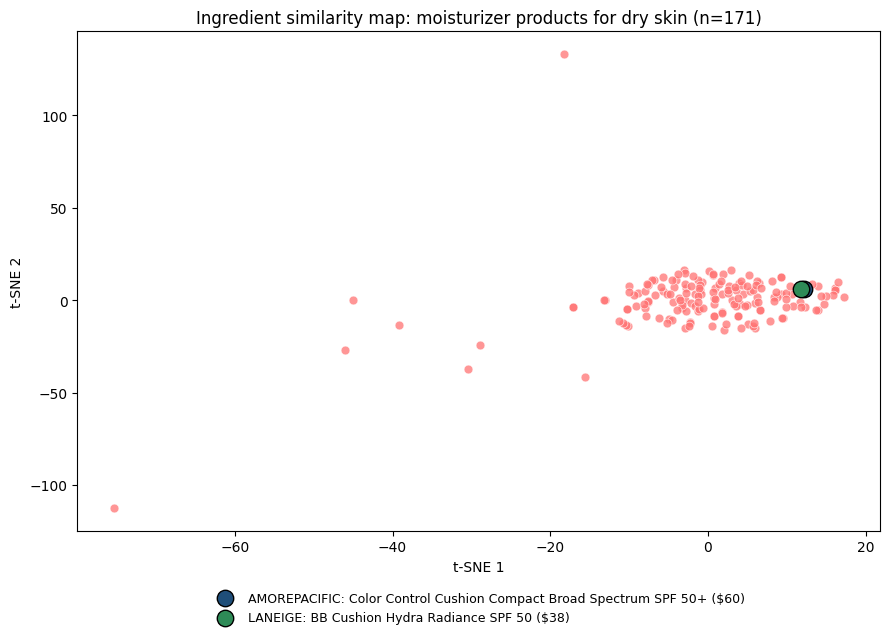

Saved to Screenshots/tsne_ingredient_map.png


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.scatter(products['X'], products['Y'], s=40, color='#FF7373', alpha=0.75, edgecolor='white', linewidth=0.5)
for idx, colour in [(product_a, '#1f4e79'), (product_b, '#2e8b57')]:
    row = products.loc[idx]
    ax.scatter(row['X'], row['Y'], s=140, color=colour, edgecolor='black', zorder=3,
               label=f"{row['Brand']}: {row['Name']} (${row['Price']})")
ax.set_title(f'Ingredient similarity map: {CATEGORY.lower()} products for {SKIN_TYPE.lower()} skin (n={M})')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), frameon=False, fontsize=9)
fig.tight_layout()

snapshot_path = REPO_ROOT / 'Screenshots' / 'tsne_ingredient_map.png'
fig.savefig(snapshot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {snapshot_path.relative_to(REPO_ROOT)}')

## 11. Recommend similar products

The map is useful for exploration, but a recommendation system should also produce a ranked answer. `recommend()` returns the products whose ingredient lists are most similar to a given product, ranked by Jaccard similarity, with an optional price limit, so users can find comparable (and sometimes cheaper or better-rated) alternatives.

In [12]:
def recommend(name, top_n=5, max_price=None):
    # Return the `top_n` products most similar in ingredients to `name`, optionally capped by price.
    idx = find_product(name)
    results = products.assign(Similarity=similarity[idx]).drop(index=idx)
    if max_price is not None:
        results = results[results['Price'] <= max_price]
    results = results.sort_values('Similarity', ascending=False).head(top_n)
    return results[['Brand', 'Name', 'Price', 'Rating', 'Similarity']].round({'Similarity': 3}).reset_index(drop=True)


liked = products.at[product_a, 'Name']
print(f'Most similar to {products.at[product_a, "Brand"]} "{liked}":')
display(recommend(liked))

# Budget example: alternatives to the most expensive product, capped at the median price of the selection
premium = products.loc[products['Price'].idxmax()]
budget = products['Price'].median()
print(f'Most similar to {premium["Brand"]} "{premium["Name"]}" (${premium["Price"]}), priced at ${budget:.0f} or less:')
display(recommend(premium['Name'], max_price=budget))

Most similar to AMOREPACIFIC "Color Control Cushion Compact Broad Spectrum SPF 50+":


,Brand,Name,Price,Rating,Similarity
0,LANEIGE,BB Cushion Hydra Radiance SPF 50,38,4.3 / 5,0.365
1,SUPERGOOP!,CC Cream Daily Correct Broad Spectrum SPF 35+ ...,34,4.4 / 5,0.189
2,LANCÔME,Visionnaire Advanced Multi-Correcting Cream,88,4.6 / 5,0.162
3,LANEIGE,Water Sleeping Mask,25,4.4 / 5,0.162
4,IT COSMETICS,Your Skin But Better™ CC+Illumination™ Cream w...,38,3.9 / 5,0.156


Most similar to FRESH "Crème Ancienne®" ($290), priced at $52 or less:


,Brand,Name,Price,Rating,Similarity
0,CAUDALIE,Vine[activ] Overnight Detox Oil,50,4.5 / 5,0.143
1,KIEHL'S SINCE 1851,Daily Reviving Concentrate,47,4.7 / 5,0.138
2,REN CLEAN SKINCARE,Evercalm™ Overnight Recovery Balm,48,4.9 / 5,0.128
3,CAUDALIE,Vinosource Intense Moisture Rescue Cream,39,4.2 / 5,0.109
4,SMASHBOX,Photo Finish Primer Water,32,4.1 / 5,0.103


## 12. Conclusion

- After cleaning, every product in the chosen category and skin type is represented by its ingredient set, and products are compared with a similarity measure suited to sets (Jaccard).
- The t-SNE map gives an intuitive, interactive overview: products that sit close together share a large part of their ingredient lists.
- The comparison in Section 9 shows the approach working in practice. Two cushion-compact products from different brands share most of their ingredients, and the LANEIGE product is cheaper and better rated.
- `recommend()` turns the analysis into a usable tool that suggests ingredient-similar alternatives, optionally within a budget.

**Limitations**

- Ingredient similarity is not the same as skin compatibility. Ingredient concentration and order, formulation, and individual sensitivities are not captured, so recommendations support a decision but are not dermatological advice.
- Product data (prices, ratings, formulas) reflects the Sephora listings at the time the dataset was collected. A small number of entries list only key ingredients rather than the full formula, and a few contain commas inside parentheses (e.g. grouped colour-index numbers), which produce minor tokenization noise.
- t-SNE layouts depend on the random seed and perplexity. Distances between nearby points are meaningful, but the overall positions of clusters are not.

**Future work:** weight ingredients by their position in the list (TF-IDF or rank weighting), flag common irritants for sensitive skin, and package the map and recommender as a small web app.